# Hybrid Identity Anomaly Detection — LANL Red-Team Evaluation

Reproduces the Identity paper's evaluation: a context-aware Isolation Forest is trained on the LANL red-team window's normal events and scored against the red-team ground truth. Reports ROC AUC (with bootstrap CI), average precision, an operating point, and single-feature baselines. Note the key finding: the `unique_pcs` feature alone out-scores the full model, because red-team lateral movement is strongly signalled by access breadth.

**Prerequisites:** the raw LANL `auth.txt.gz` and `redteam.txt.gz` in `data/raw/`, and the extracted window `data/raw/auth_window.csv`. The window is produced (time-sorted, early-exit) with:

```bash
zcat data/raw/auth.txt.gz | \
  awk -F, '$1>500000{exit} $1>=150000{print $1","$2","$4","$5","$6","$7","$8","$9}' \
  > data/raw/auth_window.csv
```
(auth.txt.gz is a large public download from the LANL Comprehensive Cyber-Security Events dataset, csr.lanl.gov.)

In [1]:
# --- notebook path shim (makes the embedded evaluation script runnable in Jupyter) ---
from pathlib import Path


def _repo_root(p):
    for a in [p, *p.parents]:
        if (a / "data" / "processed").exists():
            return a
    return p


REPO = _repo_root(Path.cwd())
(REPO / "paper" / "identity").mkdir(parents=True, exist_ok=True)
(REPO / "paper" / "identity" / "figures").mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)


Repo root: C:\Users\User\ai-cybersecurity-portfolio


In [2]:
"""
Rigorous, paper-aware evaluation of the context-aware identity anomaly detector
(Isolation Forest) against the LANL red-team ground truth.

The processed LANL slices used elsewhere in this project cover only day 1, which
predates any red-team activity. Here we extract the red-team window from the raw
auth.txt.gz (see the awk pre-filter that produces data/raw/auth_window.csv),
engineer the same nine features used by the deployed detector, fit an Isolation
Forest on the window's (assumed-normal) events, score every event, and evaluate
the ranking against the red-team labels.

Because negatives vastly outnumber positives, we keep ALL red-team positives and
a hash-based random subsample of negatives; ROC AUC is invariant to negative
subsampling, so the AUC estimate is unbiased (precision/PR are reported at the
subsampled prevalence and flagged accordingly). Behavioural aggregates
(hourly_count, unique_pcs) are computed over the FULL window before subsampling.

Produces (into paper/identity/):
  - results_identity.json
  - figures/roc.png, figures/pr.png
"""
import json
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from sklearn.ensemble import IsolationForest
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler


def _find_root(p):
    for a in [p, *p.parents]:
        if (a / "data" / "processed").exists():
            return a
    return p.parent


ROOT = REPO
DATA_RAW = ROOT / "data" / "raw"
WINDOW_CSV = DATA_RAW / "auth_window.csv"
REDTEAM = DATA_RAW / "redteam.txt.gz"
HERE = REPO / "paper" / "identity"
FIGS = HERE / "figures"; FIGS.mkdir(exist_ok=True)
RESULTS = HERE / "results_identity.json"

WINDOW = (150000, 500000)
NEG_HASH_MOD = 80          # keep ~1/80 of negatives
SEED = 42
BOOT = 1000
rng = np.random.default_rng(SEED)

COLS = ["time", "src_user", "src_pc", "dst_pc", "auth_type", "logon_type", "orientation", "success"]
FEATURES = ["hour", "day_of_week", "is_weekend", "hourly_count", "unique_pcs",
            "logon_type_code", "auth_type_code", "orientation_code", "success_code"]


def boot_ci(y, score, fn):
    n = len(y); idx = np.arange(n)
    vals = []
    for _ in range(BOOT):
        s = rng.choice(idx, n, replace=True)
        if y[s].sum() == 0 or y[s].sum() == len(s):
            continue
        vals.append(fn(y[s], score[s]))
    return (float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))) if vals else (float("nan"), float("nan"))


def main():
    # --- red-team keys in window (join on time, src_user, src_pc, per notebook) ---
    rt = pl.read_csv(REDTEAM, has_header=False, new_columns=["time", "src_user", "src_pc", "dst_pc"])
    rt = rt.filter((pl.col("time") >= WINDOW[0]) & (pl.col("time") <= WINDOW[1]))
    rt_keys = rt.select(["time", "src_user", "src_pc"]).unique().with_columns(pl.lit(1).alias("is_red"))
    print(f"red-team events in window: {rt.height}")

    lf = pl.scan_csv(WINDOW_CSV, has_header=False, new_columns=COLS)
    lf = lf.with_columns([
        ((pl.col("time") % 86400) // 3600).alias("hour"),
        ((pl.col("time") // 86400) % 7).alias("day_of_week"),
    ]).with_columns(pl.col("day_of_week").is_in([5, 6]).cast(pl.Int64).alias("is_weekend"))

    # --- behavioural aggregates over the FULL window ---
    hourly = lf.group_by(["src_user", "hour"]).agg(pl.len().alias("hourly_count")).collect(streaming=True)
    pcs = lf.group_by("src_user").agg(pl.col("src_pc").n_unique().alias("unique_pcs")).collect(streaming=True)
    print(f"users: {pcs.height:,} | (user,hour) groups: {hourly.height:,}")

    # --- label + subsample: keep all positives + ~1/MOD of negatives ---
    labelled = lf.join(rt_keys.lazy(), on=["time", "src_user", "src_pc"], how="left").with_columns(
        pl.col("is_red").fill_null(0))
    keyhash = pl.concat_str(["time", "src_user", "src_pc", "dst_pc"], separator="|").hash()
    sample = labelled.filter((pl.col("is_red") == 1) | ((keyhash % NEG_HASH_MOD) == 0)).collect(streaming=True)
    print(f"sample rows: {sample.height:,} (positives {int(sample['is_red'].sum())})")

    # --- join aggregates, encode categoricals (consistent within window) ---
    sample = sample.join(hourly, on=["src_user", "hour"], how="left").join(pcs, on="src_user", how="left")
    for col in ["logon_type", "auth_type", "orientation", "success"]:
        cats = sample[col].unique().to_list()
        mapping = {v: i for i, v in enumerate(cats)}
        sample = sample.with_columns(pl.col(col).replace_strict(mapping, default=-1).alias(f"{col}_code"))

    y = sample["is_red"].to_numpy()
    X = sample.select(FEATURES).to_numpy().astype(np.float64)

    # --- fit scaler + Isolation Forest on assumed-normal events (is_red==0) ---
    Xn = X[y == 0]
    scaler = StandardScaler().fit(Xn)
    iso = IsolationForest(n_estimators=200, random_state=SEED, n_jobs=-1).fit(scaler.transform(Xn))
    score = -iso.score_samples(scaler.transform(X))  # higher = more anomalous

    auc = roc_auc_score(y, score)
    ap = average_precision_score(y, score)
    auc_ci = boot_ci(y, score, roc_auc_score)
    # operating point: IsolationForest's own predict (contamination='auto' -> predict==-1 anomalous)
    pred = (iso.predict(scaler.transform(X)) == -1).astype(int)
    tp = int(((pred == 1) & (y == 1)).sum()); fp = int(((pred == 1) & (y == 0)).sum())
    fn = int(((pred == 0) & (y == 1)).sum()); tn = int(((pred == 0) & (y == 0)).sum())
    recall = tp / (tp + fn) if tp + fn else 0.0
    precision = tp / (tp + fp) if tp + fp else 0.0
    fpr = fp / (fp + tn) if fp + tn else 0.0

    # --- single-feature baselines (no training) ---
    baselines = {}
    for feat in ["hourly_count", "unique_pcs"]:
        s = sample[feat].to_numpy().astype(np.float64)
        baselines[feat] = {"auc": float(roc_auc_score(y, s)), "ap": float(average_precision_score(y, s))}
    baselines["random"] = {"auc": 0.5, "ap": float(y.mean())}

    # --- figures ---
    fpr_c, tpr_c, _ = roc_curve(y, score)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr_c, tpr_c, label=f"Isolation Forest (AUC={auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", lw=0.8)
    plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
    plt.title("Identity red-team detection — ROC"); plt.legend(loc="lower right"); plt.tight_layout()
    plt.savefig(FIGS / "roc.png", dpi=200); plt.close()

    prec_c, rec_c, _ = precision_recall_curve(y, score)
    plt.figure(figsize=(5, 4))
    plt.plot(rec_c, prec_c, label=f"Isolation Forest (AP={ap:.3f})")
    plt.axhline(y.mean(), color="k", ls="--", lw=0.8, label=f"chance ({y.mean():.4f})")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title("Identity red-team detection — PR"); plt.legend(loc="upper right"); plt.tight_layout()
    plt.savefig(FIGS / "pr.png", dpi=200); plt.close()

    results = {
        "window": WINDOW,
        "redteam_in_window": int(rt.height),
        "sample_rows": int(sample.height),
        "positives": int(y.sum()),
        "neg_hash_mod": NEG_HASH_MOD,
        "sampled_prevalence": float(y.mean()),
        "auc": float(auc), "auc_ci": auc_ci, "average_precision": float(ap),
        "operating_point": {"recall": recall, "precision": precision, "fpr": fpr,
                            "tp": tp, "fp": fp, "fn": fn, "tn": tn},
        "baselines": baselines,
        "config": {"seed": SEED, "iso_estimators": 200},
    }
    RESULTS.write_text(json.dumps(results, indent=2))

    print("\n==== SUMMARY ====")
    print(f"positives={int(y.sum())} sampled_negatives={int((y==0).sum())} prevalence={y.mean():.5f}")
    print(f"AUC={auc:.4f} CI={auc_ci} AP={ap:.4f}")
    print(f"operating point: recall={recall:.3f} precision={precision:.4f} FPR={fpr:.4f}")
    print(f"baselines: hourly_count AUC={baselines['hourly_count']['auc']:.3f} "
          f"unique_pcs AUC={baselines['unique_pcs']['auc']:.3f}")
    print(f"results -> {RESULTS}")


main()


red-team events in window: 46


C:\Users\User\AppData\Local\Temp\ipykernel_15808\1127326395.py:86: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  hourly = lf.group_by(["src_user", "hour"]).agg(pl.len().alias("hourly_count")).collect(streaming=True)


C:\Users\User\AppData\Local\Temp\ipykernel_15808\1127326395.py:87: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  pcs = lf.group_by("src_user").agg(pl.col("src_pc").n_unique().alias("unique_pcs")).collect(streaming=True)


users: 38,107 | (user,hour) groups: 469,246


C:\Users\User\AppData\Local\Temp\ipykernel_15808\1127326395.py:94: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  sample = labelled.filter((pl.col("is_red") == 1) | ((keyhash % NEG_HASH_MOD) == 0)).collect(streaming=True)


sample rows: 767,302 (positives 48)



==== SUMMARY ====
positives=48 sampled_negatives=767254 prevalence=0.00006
AUC=0.8534 CI=(0.8372314513056879, 0.8677757053276886) AP=0.0002
operating point: recall=1.000 precision=0.0003 FPR=0.2476
baselines: hourly_count AUC=0.423 unique_pcs AUC=0.905
results -> C:\Users\User\ai-cybersecurity-portfolio\paper\identity\results_identity.json


pr.png


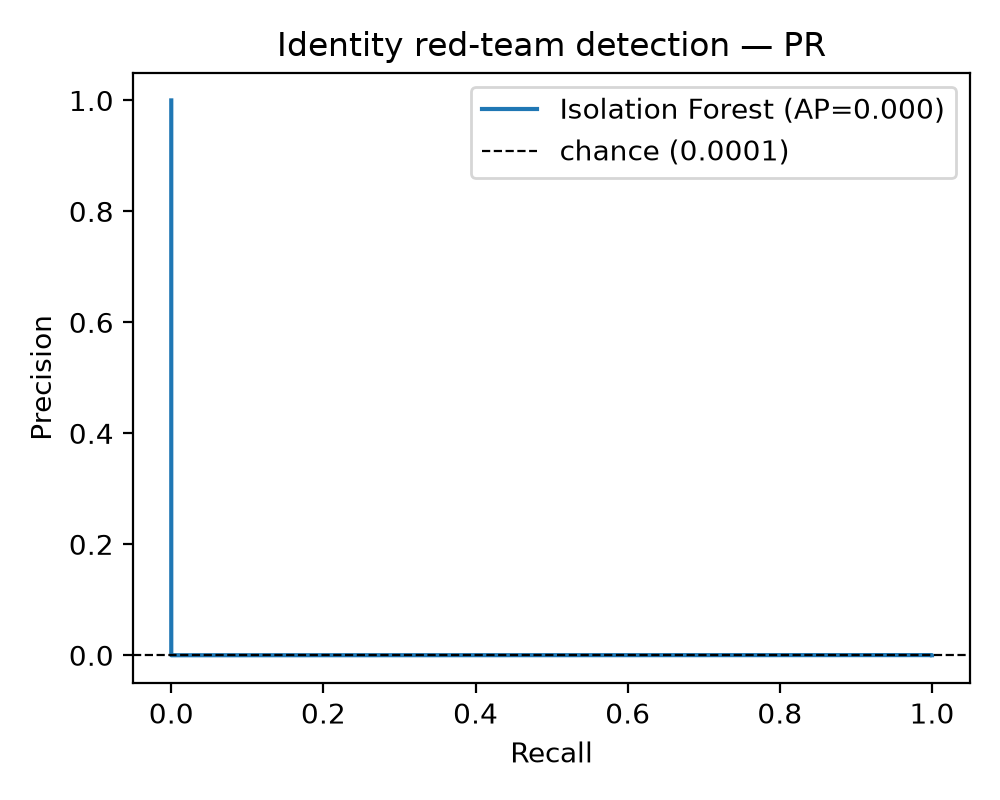

roc.png


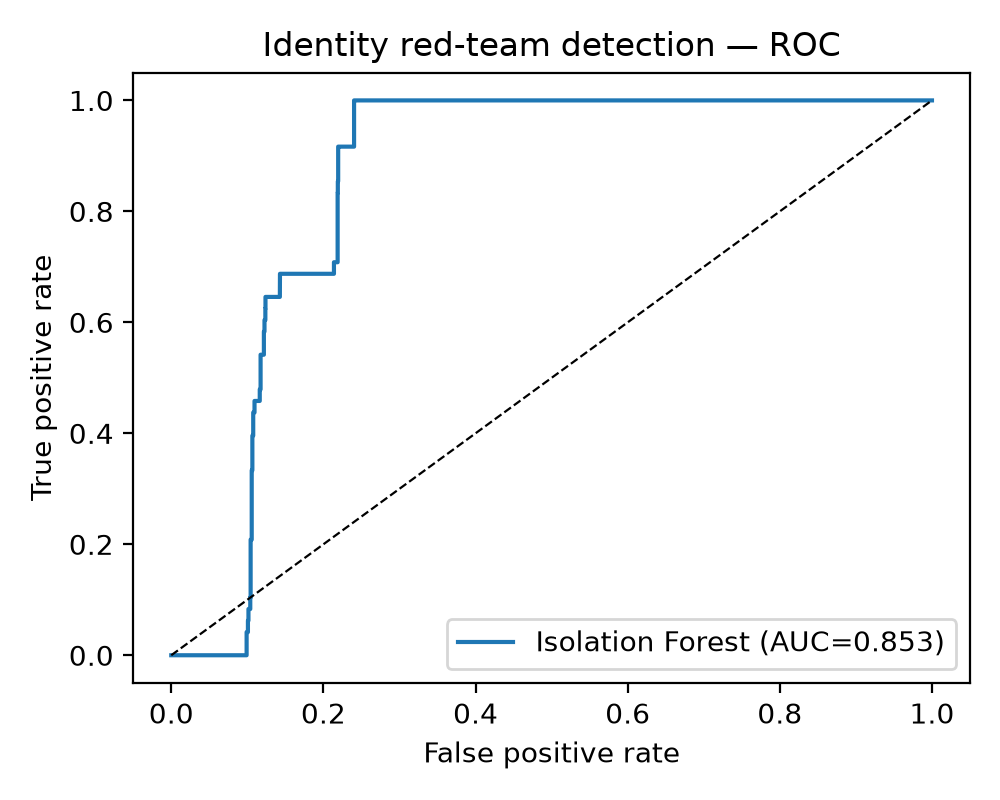

In [3]:
# --- display the result figures inline ---
import os
from IPython.display import Image, display

_figdir = REPO / "paper" / "identity" / "figures"
for _f in sorted(os.listdir(_figdir)):
    if _f.endswith(".png") and not _f.startswith("eq_"):
        print(_f)
        display(Image(str(_figdir / _f)))
